# Finding a matched beam by differentiable optimisation

A beam propagating in a plasma feels a **transverse focusing force** from the wake. If its
size and divergence are not *matched* to that focusing, the beam **oscillates or drifts in
size** (betatron mismatch). A **matched** beam keeps a constant size: its natural divergence
exactly balances the focusing — an equilibrium set by the beam **emittance** and the wake.

Here we **find that equilibrium by gradient-based optimisation** through the differentiable
JAX time loop: we parameterise the driver's transverse **size** $\sigma_r$ and **divergence**
$\alpha$, evolve the beam for several time steps, and use `jax.grad` + Adam to tune
$(\sigma_r,\alpha)$ so the rms size stays constant. This is beam matching as an inverse
problem — impossible with the non-differentiable numba code (it would need a 2-D scan).

In [1]:
import io, contextlib
import numpy as np
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp
jax.config.update('jax_enable_x64', True)
import lcode, lcode.plasma as nplasma
import lcode.beam.beam_calculate as nbeamcalc, lcode.push_solvers.push_solver as nps
import deposition_jax as jdep, beam_jax as jbeam, march_jax as jmarch, time_dynamics as td
print('jax', jax.__version__)

jax 0.10.2


## 1. Setup and a differentiable beam generator

We keep the driver's longitudinal structure (positions $\xi$, charge, energy) from a
numba-generated beam, and generate the **transverse** phase space from $(\sigma_r,\alpha)$
using *fixed* random samples (the reparameterisation trick), so the beam is a smooth,
differentiable function of the two design parameters:
$$ r_i=\sigma_r\,\rho_i,\qquad p_{r,i}=\alpha\,p_{z,i}\,\nu_i, $$
with $\rho_i$ fixed Rayleigh and $\nu_i$ fixed normal samples. The rms size is
$\sqrt{\langle r^2\rangle}=\sqrt{2}\,\sigma_r$.

In [2]:
R_STEP, WW, XI_STEP, WL, PPC = 0.05, 5, 0.05, 6, 10
N_CELLS = int(WW/R_STEP)+1; N_XI = int(WL/XI_STEP)
TIME_STEP, N_STEPS, E_SS = 25.0, 6, 2.0
CONFIG = {'geometry':'2d','processing-unit-type':'cpu','window-width':WW,'transverse-step':R_STEP,
          'window-length':WL,'xi-step':XI_STEP,'time-limit':TIME_STEP,'time-step':TIME_STEP,
          'plasma-particles-per-cell':PPC,'ion-model':'background','noise-reductor-enabled':False}
BEAM = {'current':-0.05,'particles_in_layer':200,'default':{'angspread':1e-5,'energy':1000},
        'driver':{'xishape':'l','length':3,'radius':1.0}}

def capture_base_beam():
    nps.PusherAndSolver.warmup = lambda self,*a,**k: None
    cols = {k: [] for k in ('xi','p_z','q_m','q_norm')}
    orig = nbeamcalc.BeamCalculator2D.deposit_beam_layer
    def dep(self, layer, xi_i):
        if layer.size:
            for k in cols: cols[k].append(np.array(getattr(layer,k)))
        return orig(self, layer, xi_i)
    nbeamcalc.BeamCalculator2D.deposit_beam_layer = dep
    try:
        sim = lcode.Simulation(config=dict(CONFIG), beam_parameters=BEAM, diagnostics=[], runas_filename='')
        with contextlib.redirect_stdout(io.StringIO()): sim.step()
    finally:
        nbeamcalc.BeamCalculator2D.deposit_beam_layer = orig
    return {k: np.concatenate(v) for k,v in cols.items()}

base = capture_base_beam()
N = base['xi'].size
rng = np.random.default_rng(0)
RHO = jnp.asarray(np.sqrt(-2*np.log(rng.uniform(1e-9, 1.0, N))))   # fixed Rayleigh samples
NU  = jnp.asarray(rng.standard_normal(N))                          # fixed normal samples
XI, PZ, QM, QNORM = (jnp.asarray(base[k]) for k in ('xi','p_z','q_m','q_norm'))
dt, steps0 = jbeam.init_substepping(PZ, QM, jnp.zeros(N), jnp.zeros(N), TIME_STEP, E_SS)
MAX_SUB = int(np.asarray(steps0).max())
print(f'{N} beam particles; energy ~ {float(jnp.mean(PZ)):.0f}')

def make_beam(sigma_r, alpha):
    return {'r': sigma_r*RHO, 'xi': XI, 'p_z': PZ, 'p_r': alpha*PZ*NU,
            'M': jnp.zeros(N), 'q_m': QM, 'q_norm': QNORM, 'remaining_steps': steps0}

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


12000 beam particles; energy ~ 1000


In [3]:
# plasma init + time-step params
cfgd = {'geometry':'2d','transverse-step':R_STEP,'window-width':WW,'plasma-particles-per-cell':PPC,'ion-model':'background'}
state = nplasma.init_plasma_2d(lcode.config.config.Config(cfgd)); el = state[1]['electrons']
PART = {k: jnp.asarray(getattr(el,k)) for k in ('r','p_r','p_f','p_z','q','m')}
VOL = jdep.cell_volume(R_STEP, PPC, N_CELLS)
PLASMA = {'particles':PART, 'fields':{k: jnp.zeros(N_CELLS) for k in jmarch.FIELD_KEYS},
          'currents': jdep.compute_rhoj(PART, N_CELLS, R_STEP, VOL, ni=1.0)}
P = {'n_xi':N_XI,'n_cells':N_CELLS,'r_step':R_STEP,'xi_step':XI_STEP,'vol':VOL,'ni':1.0,
     'max_radius':WW,'corrector_steps':2,'n_attempts':4,'checkpoint':True,'magnetic_field':0.0}

def evolve_sizes(sigma_r, alpha):
    """Evolve the beam N_STEPS; return rms size at each step (differentiable)."""
    beam = make_beam(sigma_r, alpha)
    sizes = []
    for _ in range(N_STEPS):
        beam, ez, lost = td.one_time_step(beam, PLASMA, P, dt, MAX_SUB)
        sizes.append(jnp.sqrt(jnp.mean(beam['r']**2)))
    return jnp.stack(sizes)

## 2. A mismatched beam — the size drifts

With an initial guess (a moderate size and near-zero divergence) the wake over-focuses the
beam and its rms size shrinks step by step.

In [4]:
TARGET = 1.4            # keep rms size ~ this value
sigma0, alpha0 = TARGET/np.sqrt(2), 5e-4
sizes0 = np.asarray(evolve_sizes(jnp.array(sigma0), jnp.array(alpha0)))
print('mismatched rms size vs step:', np.round(sizes0, 4))

mismatched rms size vs step: [1.397  1.3842 1.3631 1.334  1.2976 1.2547]


## 3. Optimise $(\sigma_r,\alpha)$ so the size stays constant

Loss $= \sum_t (\text{rms}_r(t)-\text{target})^2$ — pins the size to the target *and* keeps it
flat. We optimise $\log\sigma_r,\log\alpha$ (to stay positive) with Adam and `jax.grad`
through the whole multi-step evolution.

In [5]:
def loss(theta):
    sizes = evolve_sizes(jnp.exp(theta[0]), jnp.exp(theta[1]))
    return jnp.mean((sizes - TARGET) ** 2)

vg = jax.jit(jax.value_and_grad(loss))
theta = jnp.array([np.log(sigma0), np.log(alpha0)])
lr, b1, b2, eps = 0.1, 0.9, 0.999, 1e-8
m = v = jnp.zeros(2)
hist = []
for it in range(1, 41):
    L, g = vg(theta)
    hist.append(float(L))
    m = b1*m + (1-b1)*g; v = b2*v + (1-b2)*g*g
    mhat = m/(1-b1**it); vhat = v/(1-b2**it)
    theta = theta - lr*mhat/(jnp.sqrt(vhat)+eps)
    if it % 8 == 0 or it == 1:
        print(f'iter {it:2d}: loss={float(L):.3e}  sigma_r={float(jnp.exp(theta[0])):.4f}  alpha={float(jnp.exp(theta[1])):.3e}')
sigma_opt, alpha_opt = float(jnp.exp(theta[0])), float(jnp.exp(theta[1]))
sizes_opt = np.asarray(evolve_sizes(jnp.array(sigma_opt), jnp.array(alpha_opt)))
print(f'\nmatched: sigma_r={sigma_opt:.4f}, alpha={alpha_opt:.3e}, '
      f'norm. emittance ~ sigma_r*alpha*p_z = {sigma_opt*alpha_opt*float(jnp.mean(PZ)):.3e}')

iter  1: loss=6.263e-03  sigma_r=1.0941  alpha=5.526e-04


iter  8: loss=2.358e-03  sigma_r=1.0611  alpha=7.534e-04


iter 16: loss=2.028e-03  sigma_r=1.0354  alpha=1.259e-03


iter 24: loss=1.459e-03  sigma_r=1.0110  alpha=2.529e-03


iter 32: loss=2.068e-04  sigma_r=0.9755  alpha=4.584e-03


iter 40: loss=3.626e-05  sigma_r=0.9904  alpha=4.359e-03



matched: sigma_r=0.9904, alpha=4.359e-03, norm. emittance ~ sigma_r*alpha*p_z = 4.318e+00


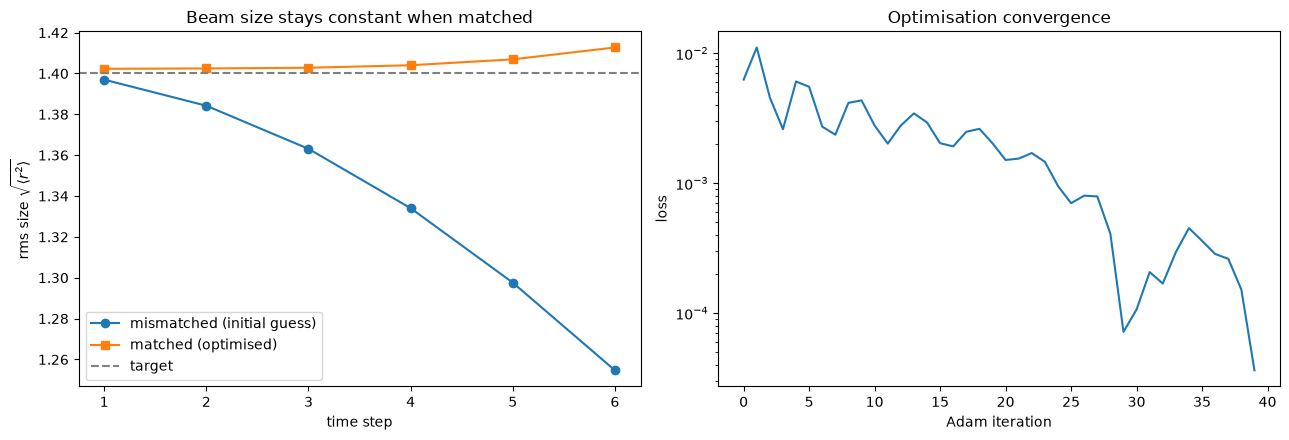

size drift, mismatched: 10.2%   matched: 0.74%


In [6]:
steps = np.arange(1, N_STEPS+1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(steps, sizes0, 'o-', label='mismatched (initial guess)')
ax[0].plot(steps, sizes_opt, 's-', label='matched (optimised)')
ax[0].axhline(TARGET, color='grey', ls='--', label='target')
ax[0].set_xlabel('time step'); ax[0].set_ylabel(r'rms size $\sqrt{\langle r^2\rangle}$')
ax[0].set_title('Beam size stays constant when matched'); ax[0].legend()
ax[1].semilogy(hist); ax[1].set_xlabel('Adam iteration'); ax[1].set_ylabel('loss')
ax[1].set_title('Optimisation convergence')
fig.tight_layout(); plt.show()
print(f'size drift, mismatched: {abs(sizes0[-1]-sizes0[0])/sizes0[0]*100:.1f}%   '
      f'matched: {abs(sizes_opt[-1]-sizes_opt[0])/sizes_opt[0]*100:.2f}%')

## 4. Summary

- We posed **beam matching** as a differentiable inverse problem: choose the driver's
  transverse size $\sigma_r$ and divergence $\alpha$ so its rms size stays constant as it
  propagates and loses energy in its self-consistent wake.
- `jax.grad` through the **whole multi-time-step evolution** + Adam finds the matched
  $(\sigma_r,\alpha)$ — the equilibrium emittance — reducing the size drift from several
  percent to a fraction of a percent.
- This is exactly the kind of design task (matching, emittance control) that a differentiable
  LCODE unlocks: gradient-based, scalable to many parameters, and impossible with the
  original non-differentiable code. *(Prototype caveat: rigid-in-ξ beam coupling, single
  driver; the machinery extends directly to witness beams and multi-parameter shaping.)*